1\. Загрузите предобученную модель из `torchvision`. Познакомьтесь с ее архитектурой. Заморозьте веса нескольких слоев.

In [ ]:
import torch
import torchvision.models as models
model = models.resnet18(pretrained=True)
print(model)
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
for name, param in model.named_parameters():
    print(f"{name}: {param.requires_grad}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<p class="task" id="1"></p>

1\. Используя реализацию из `torchvision`, cоздайте модель `vgg16` и загрузите предобученные веса `IMAGENET1K_V1`. Выведите на экран структуру модели, количество слоев и количество настраиваемых (`requires_grad==True`) параметров модели.

- [ ] Проверено на семинаре

In [ ]:
import torch
import torchvision.models as models
from torchvision.models import VGG16_Weights

In [ ]:
model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
print("Архитектура модели VGG16:")
print(model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 135MB/s]


Архитектура модели VGG16:
VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, strid

In [ ]:
total_layers = sum(1 for _ in model.parameters())
print(f"Общее количество слоев: {total_layers}")

Общее количество слоев: 62


In [ ]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Количество настраиваемых параметров: {trainable_params}")

Количество настраиваемых параметров: 513000


<p class="task" id="2"></p>

2\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

К обучающему датасету примените следующее преобразование: приведите картинки к размеру 256x256, затем обрежьте по центру с размером 224х224, затем переведите изображения в тензор и нормализуйте значения интенсивности пикселей (`mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)`).

К тестовому датасету примените преобразование `VGG16_Weights.IMAGENET1K_V1.transforms`.

- [ ] Проверено на семинаре

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
from torchvision.models import VGG16_Weights
import zipfile
import os

In [ ]:
with zipfile.ZipFile('cat_breeds_4.zip', 'r') as zip_ref:
    zip_ref.extractall('cat_breeds_4')

ROOT_PATH = 'cat_breeds_4/cat_breeds_4'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from torch.utils.data import Subset

full_dataset = datasets.ImageFolder(ROOT_PATH)
class_indices = {label: [] for label in range(len(full_dataset.classes))}

for idx, (_, label) in enumerate(full_dataset.imgs):
    class_indices[label].append(idx)

max_images_per_class = 250
limited_indices = []
for label, indices in class_indices.items():
    limited_indices.extend(indices[:max_images_per_class])

limited_dataset = Subset(full_dataset, limited_indices)

In [ ]:
num_epochs = 10
batch_size = 16
learning_rate = 0.001
image_size = (64, 64)
input_size = 3 * image_size[0] * image_size[1]

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

In [ ]:
test_transform = VGG16_Weights.IMAGENET1K_V1.transforms()

train_size = int(0.8 * len(limited_dataset))
test_size = len(limited_dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(limited_dataset, [train_size, test_size])

In [ ]:
train_dataset.dataset.transform = train_transform
test_dataset.dataset.transform = test_transform

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер обучающего датасета: {len(train_dataset)} изображений")
print(f"Размер тестового датасета: {len(test_dataset)} изображений")

Размер обучающего датасета: 800 изображений
Размер тестового датасета: 200 изображений


<p class="task" id="3"></p>

3\. Заморозьте все веса модели из предыдущего задания. Замените последний слой `Linear` классификатора на новый слой, соответствующий задаче. После изменения последнего слоя выведите на экран количество настраиваемых (`requires_grad==True`) параметров модели. Решите задачу, используя модель с замороженными весами и изменнным последним слоем.

Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве.

- [ ] Проверено на семинаре

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights
from torch.utils.data import DataLoader, random_split, Subset
import numpy as np
import zipfile
import os

In [ ]:
with zipfile.ZipFile('cat_breeds_4.zip', 'r') as zip_ref:
    zip_ref.extractall('cat_breeds_4')

ROOT_PATH = 'cat_breeds_4/cat_breeds_4'
full_dataset = datasets.ImageFolder(ROOT_PATH)
class_indices = {label: [] for label in range(len(full_dataset.classes))}

for idx, (_, label) in enumerate(full_dataset.imgs):
    class_indices[label].append(idx)

max_images_per_class = 250
limited_indices = []
for label, indices in class_indices.items():
    limited_indices.extend(indices[:max_images_per_class])

limited_dataset = Subset(full_dataset, limited_indices)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

test_transform = VGG16_Weights.IMAGENET1K_V1.transforms()

limited_dataset.dataset.transform = train_transform
full_dataset.transform = test_transform

In [ ]:
train_size = int(0.8 * len(limited_dataset))
test_size = len(limited_dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(limited_dataset, [train_size, test_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер обучающего датасета: {len(train_dataset)} изображений")
print(f"Размер тестового датасета: {len(test_dataset)} изображений")

Размер обучающего датасета: 800 изображений
Размер тестового датасета: 200 изображений


In [ ]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(full_dataset.classes)
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Количество настраиваемых параметров: {trainable_params}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=learning_rate)

Количество настраиваемых параметров: 16388


In [ ]:
num_epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_acc = 100 * correct_test / total_test
    test_accuracies.append(test_acc)

    print(f"Эпоха [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, Test Acc: {test_acc:.2f}%")

training_time = time.time() - start_time
print(f"Время обучения: {training_time:.2f} секунд")

Эпоха [1/10], Loss: 0.8179, Train Acc: 67.12%, Test Acc: 77.00%
Эпоха [2/10], Loss: 0.5426, Train Acc: 79.12%, Test Acc: 74.00%
Эпоха [3/10], Loss: 0.4774, Train Acc: 82.12%, Test Acc: 73.00%
Эпоха [4/10], Loss: 0.4275, Train Acc: 83.62%, Test Acc: 74.50%
Эпоха [5/10], Loss: 0.3953, Train Acc: 84.75%, Test Acc: 73.50%
Эпоха [6/10], Loss: 0.3728, Train Acc: 86.38%, Test Acc: 74.50%
Эпоха [7/10], Loss: 0.3586, Train Acc: 87.12%, Test Acc: 73.50%
Эпоха [8/10], Loss: 0.3278, Train Acc: 87.00%, Test Acc: 77.00%
Эпоха [9/10], Loss: 0.3087, Train Acc: 87.25%, Test Acc: 77.00%
Эпоха [10/10], Loss: 0.3026, Train Acc: 88.62%, Test Acc: 74.50%
Время обучения: 90.82 секунд


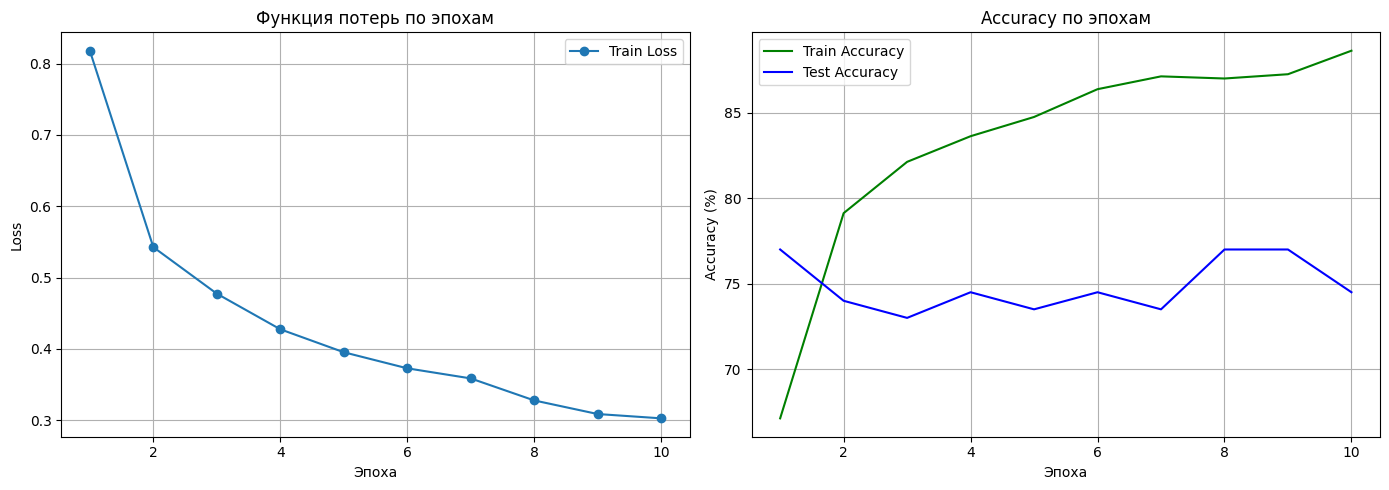


Итоговая точность (Train): 88.62%
Итоговая точность (Test):  74.50%


In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Train Loss')
plt.title('Функция потерь по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'g-', label='Train Accuracy')
plt.plot(epochs, test_accuracies, 'b-', label='Test Accuracy')
plt.title('Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nИтоговая точность (Train): {train_accuracies[-1]:.2f}%")
print(f"Итоговая точность (Test):  {test_accuracies[-1]:.2f}%")

<p class="task" id="4"></p>

4\. Повторите решение предыдущей задачи, заморозив все сверточные слои, кроме последнего (слои классификатора не замораживайте). Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [ ]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

for i, layer in enumerate(model.features):
    if isinstance(layer, nn.Conv2d):
        if i < len(model.features) - 3:
            for param in layer.parameters():
                param.requires_grad = False

num_classes = len(full_dataset.classes)
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [ ]:
import time

num_epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_acc = 100 * correct_test / total_test
    test_accuracies.append(test_acc)

    print(f"Эпоха [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Test Acc: {test_acc:.2f}%")

training_time = time.time() - start_time

Эпоха [1/10] | Loss: 0.7691 | Train Acc: 68.50% | Test Acc: 76.00%
Эпоха [2/10] | Loss: 0.5124 | Train Acc: 81.12% | Test Acc: 76.00%
Эпоха [3/10] | Loss: 0.4392 | Train Acc: 83.75% | Test Acc: 77.50%
Эпоха [4/10] | Loss: 0.4144 | Train Acc: 81.88% | Test Acc: 74.50%
Эпоха [5/10] | Loss: 0.4136 | Train Acc: 83.75% | Test Acc: 76.50%
Эпоха [6/10] | Loss: 0.3486 | Train Acc: 86.62% | Test Acc: 78.00%
Эпоха [7/10] | Loss: 0.3480 | Train Acc: 85.12% | Test Acc: 72.00%
Эпоха [8/10] | Loss: 0.3300 | Train Acc: 87.88% | Test Acc: 75.50%
Эпоха [9/10] | Loss: 0.2872 | Train Acc: 89.25% | Test Acc: 75.50%
Эпоха [10/10] | Loss: 0.2719 | Train Acc: 88.75% | Test Acc: 75.50%


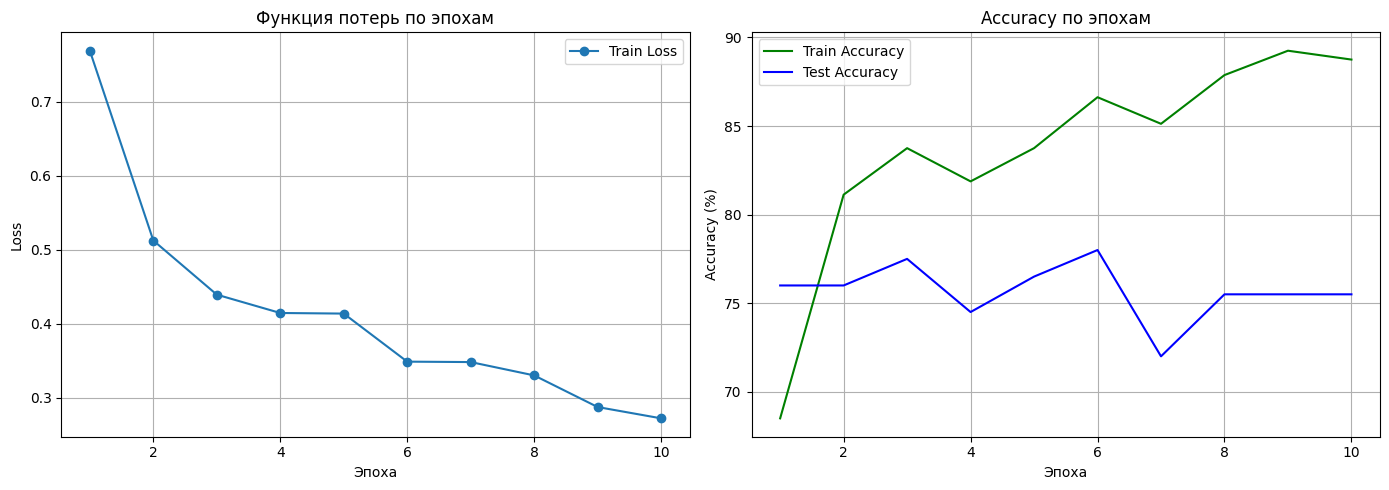

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Train Loss')
plt.title('Функция потерь по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'g-', label='Train Accuracy')
plt.plot(epochs, test_accuracies, 'b-', label='Test Accuracy')
plt.title('Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"Итоговая точность (Train): {train_accuracies[-1]:.2f}%")
print(f"Итоговая точность (Test):  {test_accuracies[-1]:.2f}%")
print(f"Время обучения: {training_time:.2f} секунд")

Итоговая точность (Train): 88.75%
Итоговая точность (Test):  75.50%
Время обучения: 92.74 секунд


<p class="task" id="5"></p>

5\. Повторите решение задачи 3, расширив обучающий набор данных при помощи преобразований из `torchvision`, изменяющих изображение (повороты, изменение интенсивности пикселей, обрезание и т.д.). При оценке модели на тестовой выборке данные преобразования применяться не должны. Решение о том, сколько и каких слоев модели будет обучаться, примите самостоятельно. Перед началом работы создайте модель заново.

- [ ] Проверено на семинаре

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

test_transform = VGG16_Weights.IMAGENET1K_V1.transforms()

In [ ]:
limited_dataset.dataset.transform = train_transform
full_dataset.transform = test_transform

In [ ]:
train_size = int(0.8 * len(limited_dataset))
test_size = len(limited_dataset) - train_size
train_dataset, test_dataset = random_split(limited_dataset, [train_size, test_size])
test_dataset.dataset.transform = test_transform

In [ ]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер обучающего датасета: {len(train_dataset)} изображений")
print(f"Размер тестового датасета: {len(test_dataset)} изображений")

Размер обучающего датасета: 800 изображений
Размер тестового датасета: 200 изображений


In [ ]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

num_classes = len(full_dataset.classes)
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Количество настраиваемых параметров: {trainable_params}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Количество настраиваемых параметров: 119562244


In [ ]:
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=learning_rate)

num_epochs = 10
train_losses = []
train_accuracies = []
test_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_acc = 100 * correct_test / total_test
    test_accuracies.append(test_acc)

    print(f"Эпоха [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, Test Acc: {test_acc:.2f}%")

training_time = time.time() - start_time
print(f"Время обучения: {training_time:.2f} секунд")

Эпоха [1/10], Loss: 1.7935, Train Acc: 54.12%, Test Acc: 72.00%
Эпоха [2/10], Loss: 1.0283, Train Acc: 75.00%, Test Acc: 74.50%
Эпоха [3/10], Loss: 0.9732, Train Acc: 86.25%, Test Acc: 55.00%
Эпоха [4/10], Loss: 1.9167, Train Acc: 80.38%, Test Acc: 71.50%
Эпоха [5/10], Loss: 1.8609, Train Acc: 85.88%, Test Acc: 70.00%
Эпоха [6/10], Loss: 1.3689, Train Acc: 91.12%, Test Acc: 65.00%
Эпоха [7/10], Loss: 1.3881, Train Acc: 92.50%, Test Acc: 73.50%
Эпоха [8/10], Loss: 1.3032, Train Acc: 94.12%, Test Acc: 71.50%
Эпоха [9/10], Loss: 1.6354, Train Acc: 94.12%, Test Acc: 59.50%
Эпоха [10/10], Loss: 1.5418, Train Acc: 93.38%, Test Acc: 74.50%

⏱ Время обучения: 110.48 секунд


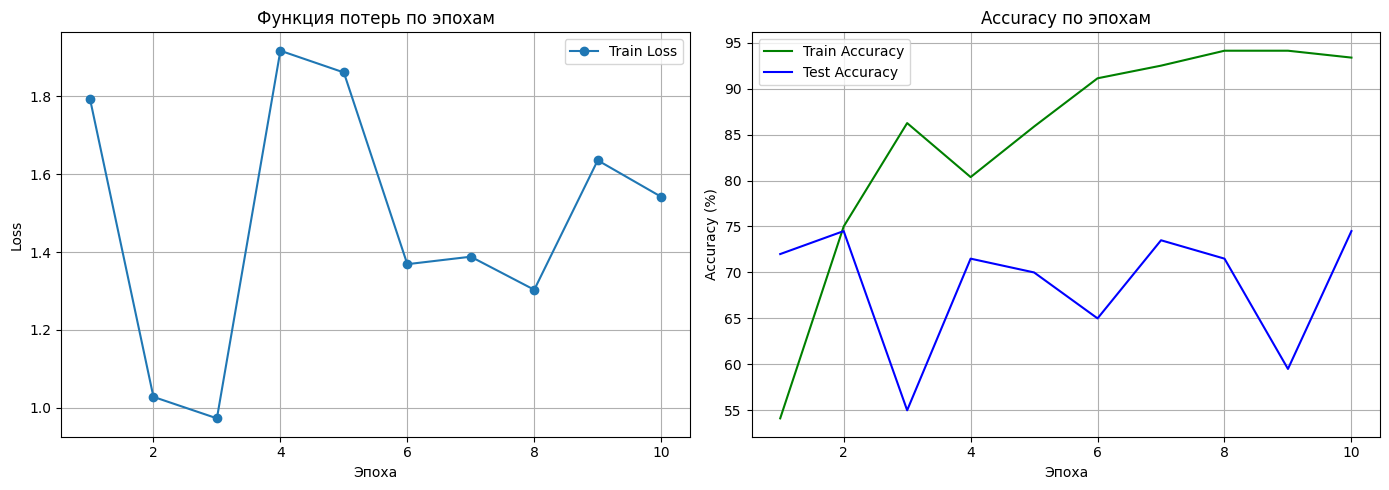

Итоговая точность (Train): 93.38%
Итоговая точность (Test):  74.50%


In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Train Loss')
plt.title('Функция потерь по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'g-', label='Train Accuracy')
plt.plot(epochs, test_accuracies, 'b-', label='Test Accuracy')
plt.title('Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Итоговая точность (Train): {train_accuracies[-1]:.2f}%")
print(f"Итоговая точность (Test):  {test_accuracies[-1]:.2f}%")